In [2]:
import pandas as pd
df=pd.read_csv("calories.csv")
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [3]:
print(df.shape)

(15000, 9)


In [4]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [6]:
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

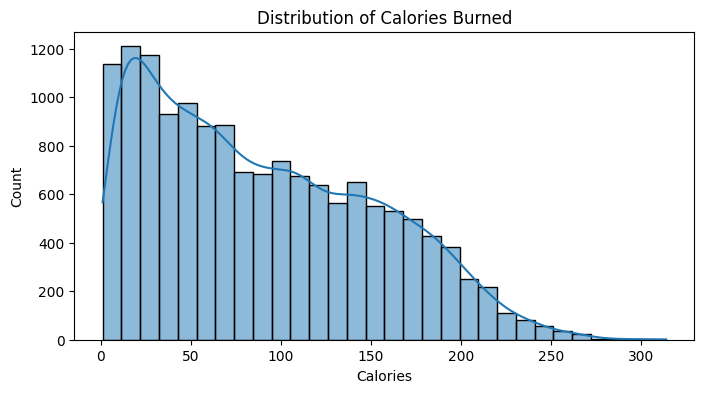

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df['Calories'], bins=30, kde=True)
plt.title("Distribution of Calories Burned")
plt.show()

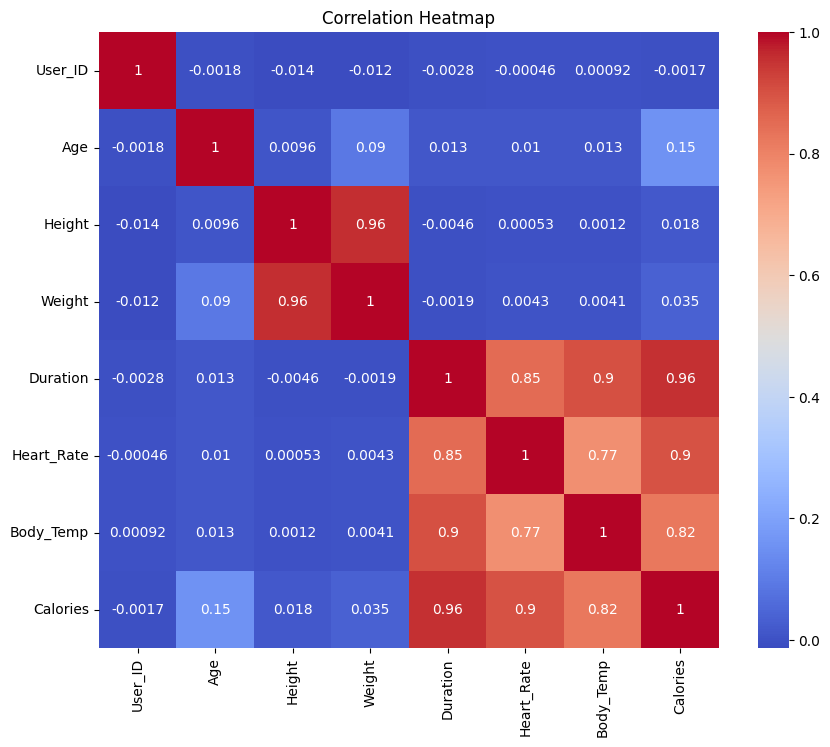

In [ ]:
# Correlation heatmap 
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [10]:
df = df.drop('User_ID', axis=1)

In [11]:
df['Gender'] = df['Gender'].map({'male': 1, 'female': 0})

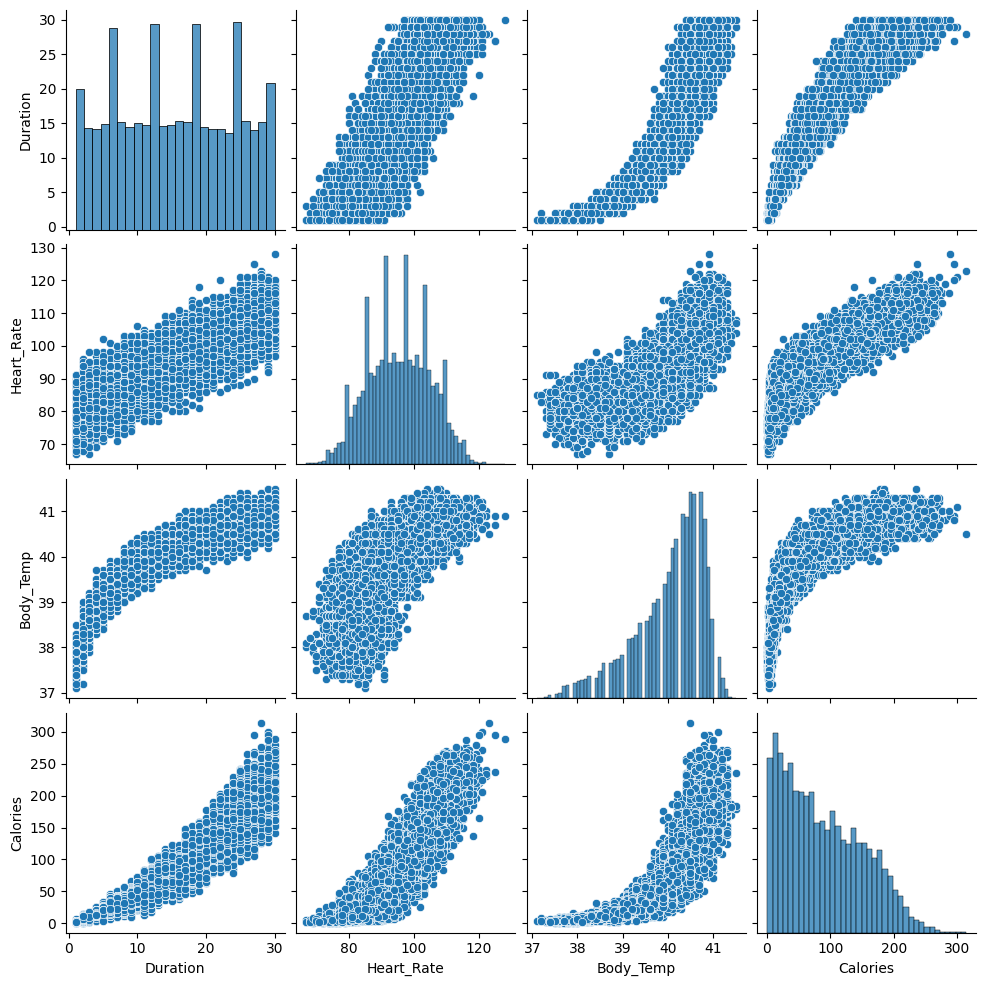

In [12]:
sns.pairplot(df[['Duration', 'Heart_Rate', 'Body_Temp', 'Calories']])
plt.show()

In [13]:
X = df.drop('Calories', axis=1)
y = df['Calories']

print(X.shape)
print(y.shape)

(15000, 7)
(15000,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(12000, 7)
(3000, 7)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [16]:
print(X_train.shape)
print(X_test.shape)

(12000, 7)
(3000, 7)


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# 1. Create model
model = LinearRegression()

# 2. Train model
model.fit(X_train_scaled, y_train)

# 3. Predict on test data
y_pred = model.predict(X_test_scaled)

# 4. Evaluate
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", r2)
print("MSE:     ", mse)
print("RMSE:    ", rmse)
print("MAE:     ", mae)

R² Score: 0.9672937151257295
MSE:      131.99574575081695
RMSE:     11.488940149152878
MAE:      8.441513553849704


In [18]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coefficients)

      Feature  Coefficient
4    Duration    55.026936
5  Heart_Rate    18.993007
1         Age     8.499936
3      Weight     4.296298
0      Gender    -0.687084
2      Height    -2.413582
6   Body_Temp   -13.179476


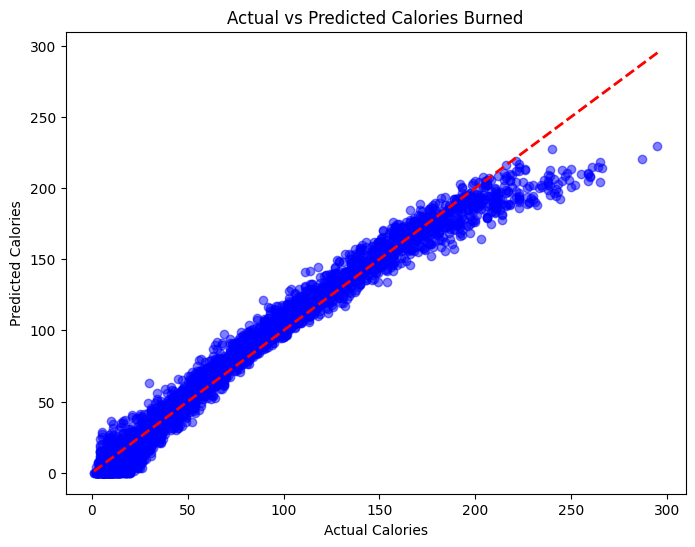

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories Burned")
plt.show()

In [25]:
y_pred = np.maximum(y_pred, 0)

In [27]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
print("CV R² Scores:", scores)
print("Mean CV R²:  ", scores.mean())

CV R² Scores: [0.96629136 0.96595964 0.96809304 0.96776439 0.96703128]
Mean CV R²:   0.9670279393988712


In [29]:
import pickle

with open('calories_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


In [30]:
print(X.columns)

Index(['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp'],
      dtype='str')
